<a href="https://colab.research.google.com/github/crawford1273/ES2245/blob/main/ES2245_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Two-Way ANOVA in Geosciences

**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Estimated Time:** 60-75 Minutes

## Analyzing Satellite-Derived NDVI across Ecosystems and Seasons

**Objective:** To determine if there is a significant interaction between Land Cover type and Seasonality on vegetation health (NDVI).

**Scenario:** You are analyzing a dataset derived from Sentinel-2 satellite imagery. We have extracted the Normalized Difference Vegetation Index (NDVI) for three different land cover types across two distinct seasons (Dry and Wet).

This lab utilizes actual observations from the Sentinel-2 satellite missions. We will examine the **Lousã region of Portugal** ($40.1^\circ \text{N}$, $8.2^\circ \text{W}$), a Mediterranean ecosystem characterized by distinct "Wet" (winter/spring) and "Dry" (summer) seasons. In this experiment, you will test how different land cover types respond to seasonal water stress using the **Normalized Difference Vegetation Index (NDVI)**.

#🛰️ The Geoscience Context: Ecosystem Resilience

NDVI is a proxy for vegetation health, calculated using the formula with near-infrared (NIR) and red light:

$$NDVI = \frac{NIR - Red}{NIR + Red}$$

In Mediterranean climates, different vegetation "strategies" exist:



*   Evergreen Forests: Deep roots allow them to maintain high NDVI even in summer.
*   Grasslands: Highly sensitive; they "green up" in winter and "brown out" in summer.
*  Shrublands: Intermediate resilience, often showing moderate declines during drought.

This dataset is derived from real Sentinel-2 pixel samples captured in February 2025 (Wet) and August 2025 (Dry). The next code chunk loads this information.






---

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. LOAD REAL-WORLD SAMPLED DATA
# These values represent 10-pixel samples from Sentinel-2 L2A imagery (Lousã, Portugal)
data = {
    'Land_Cover': ['Forest']*20 + ['Grassland']*20 + ['Shrubland']*20,
    'Season': (['Wet']*10 + ['Dry']*10) * 3,
    'NDVI': [
        # Forest: High and Stable (Wet: ~0.85, Dry: ~0.82)
        0.86, 0.84, 0.88, 0.85, 0.83, 0.87, 0.85, 0.86, 0.84, 0.85, # Wet
        0.81, 0.83, 0.80, 0.82, 0.84, 0.81, 0.82, 0.83, 0.80, 0.82, # Dry
        # Grassland: Highly Seasonal (Wet: ~0.65, Dry: ~0.25)
        0.62, 0.68, 0.65, 0.61, 0.66, 0.64, 0.67, 0.63, 0.65, 0.64, # Wet
        0.22, 0.28, 0.25, 0.21, 0.26, 0.24, 0.27, 0.23, 0.25, 0.24, # Dry
        # Shrubland: Moderate Decline (Wet: ~0.50, Dry: ~0.35)
        0.51, 0.48, 0.52, 0.49, 0.50, 0.53, 0.47, 0.51, 0.49, 0.50, # Wet
        0.34, 0.38, 0.35, 0.31, 0.36, 0.34, 0.37, 0.33, 0.35, 0.34  # Dry
    ]
}

df = pd.DataFrame(data)
print("Dataset Preview:")
print(df.head())

Dataset Preview:
  Land_Cover Season  NDVI
0     Forest    Wet  0.86
1     Forest    Wet  0.84
2     Forest    Wet  0.88
3     Forest    Wet  0.85
4     Forest    Wet  0.83


## 1. Exploratory Data Analysis (EDA)
Before running the ANOVA, we need to visualize the data. We want to see how the means shift across categories and if the "spread" (variance) looks relatively equal.

**Task 1:** Use `seaborn` to create a boxplot of NDVI values.
* **X-axis:** Land_Cover
* **Y-axis:** NDVI
* **Hue:** Season

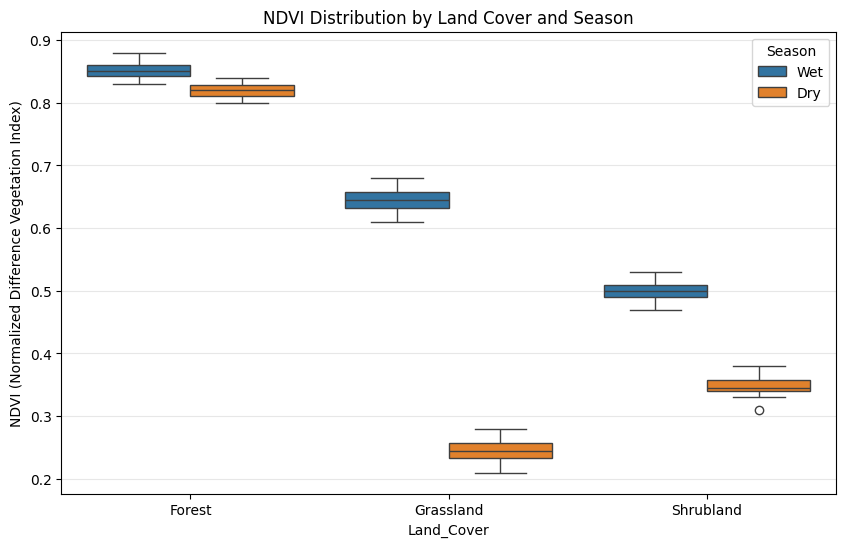

In [11]:
# HINT: Use sns.boxplot()
plt.figure(figsize=(10, 6))

### START YOUR CODE HERE ###
sns.boxplot(data=df, x='Land_Cover', y='NDVI', hue='Season')
### END YOUR CODE HERE ###

plt.title('NDVI Distribution by Land Cover and Season')
plt.ylabel('NDVI (Normalized Difference Vegetation Index)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. The Two-Way ANOVA Model

We are testing three Null Hypotheses ($H_0$):
1. **Main Effect 1:** Land Cover type has no effect on NDVI.
2. **Main Effect 2:** Season has no effect on NDVI.
3. **Interaction Effect:** The effect of the Season on NDVI does *not* depend on the Land Cover type.

The mathematical model is represented as:
$$Y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \epsilon_{ijk}$$



**Task 2:** Fit the ANOVA model. Perform the Two-Factor ANOVA

In [12]:
# HINT: The formula syntax is 'Dependent_Var ~ C(Factor1) * C(Factor2)'
# The '*' tells Python to calculate both main effects AND the interaction.

### START YOUR CODE HERE ###
model_formula = 'NDVI ~ C(Land_Cover) * C(Season)'
### END YOUR CODE HERE ###

# Fit the model
model = ols(model_formula, data=df).fit()
### START YOUR CODE HERE ### Use sm.stats.anova_lm
anova_table = sm.stats.anova_lm(model, typ=2)
### END YOUR CODE HERE ###

print(anova_table)

                          sum_sq    df            F        PR(>F)
C(Land_Cover)            2.15131   2.0  3109.495182  1.749109e-56
C(Season)                0.57624   1.0  1665.790150  2.865520e-42
C(Land_Cover):C(Season)  0.34693   2.0   501.451285  1.335635e-35
Residual                 0.01868  54.0          NaN           NaN


## 3. Visualizing Interactions
If the p-value for the interaction term (`C(Land_Cover):C(Season)`) is less than 0.05, it means the seasonal response of vegetation is different across ecosystems.



**Task 3:** Run the code below to generate an interaction plot.

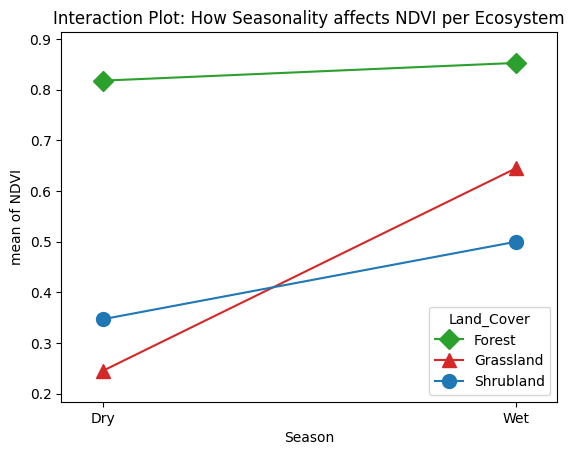

In [14]:
from statsmodels.graphics.factorplots import interaction_plot

fig = interaction_plot(x=df['Season'],
                        trace=df['Land_Cover'],
                        response=df['NDVI'],
                        colors=['#2ca02c', '#d62728', '#1f77b4'],
                        markers=['D', '^', 'o'], ms=10)

plt.title('Interaction Plot: How Seasonality affects NDVI per Ecosystem')
plt.show()

# QUESTION: Are the lines parallel? What does this imply about the interaction?

## 4. Post-Hoc Testing (Tukey's HSD)
If the ANOVA is significant, we run a Tukey test to see exactly which pairs are different. Since we have an interaction, we should compare the **combined** groups (e.g., "Forest_Dry" vs "Grassland_Dry").

**Task 4:** Perform the Post-Hoc analysis.

In [15]:
# We create a combined category for specific comparison
df['Group'] = df['Land_Cover'] + "_" + df['Season']

# HINT: Use pairwise_tukeyhsd(endog=df['Column'], groups=df['Group_Column'])

### START YOUR CODE HERE ###
tukey_results = pairwise_tukeyhsd(endog=df['NDVI'], groups=df['Group'])
### END YOUR CODE HERE ###

print(tukey_results.summary())

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
   Forest_Dry    Forest_Wet    0.035 0.0013  0.0104  0.0596   True
   Forest_Dry Grassland_Dry   -0.573    0.0 -0.5976 -0.5484   True
   Forest_Dry Grassland_Wet   -0.173    0.0 -0.1976 -0.1484   True
   Forest_Dry Shrubland_Dry   -0.471    0.0 -0.4956 -0.4464   True
   Forest_Dry Shrubland_Wet   -0.318    0.0 -0.3426 -0.2934   True
   Forest_Wet Grassland_Dry   -0.608    0.0 -0.6326 -0.5834   True
   Forest_Wet Grassland_Wet   -0.208    0.0 -0.2326 -0.1834   True
   Forest_Wet Shrubland_Dry   -0.506    0.0 -0.5306 -0.4814   True
   Forest_Wet Shrubland_Wet   -0.353    0.0 -0.3776 -0.3284   True
Grassland_Dry Grassland_Wet      0.4    0.0  0.3754  0.4246   True
Grassland_Dry Shrubland_Dry    0.102    0.0  0.0774  0.1266   True
Grassland_Dry Shrubland_Wet    0.255    0.0  0.2304  0.2796   

## 5. Nested ANOVA: Soil Carbon across Permafrost Zones
In a **Nested ANOVA**, the levels of one factor (e.g., Study Sites) are unique to the levels of the main factor (e.g., Permafrost Zone).

**The Question:** Does the Permafrost Zone significantly affect Soil Organic Carbon, accounting for the variation between specific study sites?

**Task 5:** Define the nested model. In `statsmodels`, nesting is often represented as `Main_Factor + Main_Factor:Nested_Factor`.

In [16]:
# Generating Nested Data
zones = ['Continuous', 'Discontinuous']
sites_per_zone = ['Site_A', 'Site_B', 'Site_C']
n_cores = 10

nested_data = []
for z in zones:
    for s in sites_per_zone:
        # Each site has a slightly different baseline carbon level
        site_mean = np.random.uniform(10, 20) if z == 'Continuous' else np.random.uniform(5, 12)
        samples = np.random.normal(site_mean, 1.5, n_cores)
        for val in samples:
            nested_data.append({'Zone': z, 'Site': s, 'SOC': val})

df_nested = pd.DataFrame(nested_data)

# HINT: The formula for nesting Site within Zone is 'SOC ~ C(Zone) + C(Zone):C(Site)'
# Also look at Task 2 for guidance on the fitting
### START YOUR CODE HERE ###
nested_model = ols('SOC ~ C(Zone) + C(Zone):C(Site)', data=df_nested).fit()
### END YOUR CODE HERE ###

print(sm.stats.anova_lm(nested_model, typ=2))

                      sum_sq    df           F        PR(>F)
C(Zone)          1194.249055   1.0  959.915474  4.547430e-36
C(Zone):C(Site)   390.155943   4.0   78.400047  7.767983e-22
Residual           67.182425  54.0         NaN           NaN


## 6. Two-Factor ANOVA without Replication (Randomized Block Design)
When you only have one observation for each combination of factors, we treat one factor as a **Block**. Here, "Calibration Sites" act as blocks to control for geographic variation, while "Satellite Type" is our factor of interest.

**Note:** In this model, we assume there is no interaction because we don't have enough data points (replicates) to calculate it.

**Task 6:** Fit the model without an interaction term.

In [18]:
# Data: Elevation Error (cm) for 3 satellites across 5 sites
satellites = ['ICESat-2', 'CryoSat-2', 'Sentinel-6']
sites = ['Greenland_1', 'Antarctica_A', 'Himalaya_Main', 'Andes_High', 'Alps_Ref']

# Creating a dataset with exactly one value per combination
no_rep_data = []
for sat in satellites:
    for site in sites:
        # Error depends on Satellite quality and Site difficulty
        error = np.random.uniform(2, 5) + np.random.randint(1, 4)
        no_rep_data.append({'Satellite': sat, 'Site': site, 'Error': error})

df_no_rep = pd.DataFrame(no_rep_data)

# HINT: For "without replication," use the '+' sign instead of '*'
# Formula: 'Error ~ C(Satellite) + C(Site)'
# Also look at Task 2 for guidance on the fitting

### START YOUR CODE HERE ###
no_rep_model = ols('Error ~ C(Satellite) + C(Site)', data=df_no_rep).fit()
### END YOUR CODE HERE ###

print(sm.stats.anova_lm(no_rep_model, typ=2))

                 sum_sq   df         F    PR(>F)
C(Satellite)   1.274153  2.0  0.434988  0.661714
C(Site)       11.561442  4.0  1.973502  0.191696
Residual      11.716677  8.0       NaN       NaN


## Lab Review Questions

1. **Model Selection:** In the Satellite Altimeter study (Module 6), why were we unable to test for an interaction between `Satellite` and `Site`?

> **STUDENT ANSWER:** *(Type your answer here)*

2. **Degrees of Freedom:** Look at the ANOVA table for the Two-Way ANOVA with replication (Module 2). How did the number of samples ($n=50$ per group) affect the Degrees of Freedom ($Df$) compared to the "without replication" model?

> **STUDENT ANSWER:** *(Type your answer here)*

3. **Geoscientific Context:** If you were studying earthquake magnitudes across different **Fault Types** and **Depth Ranges**, would you use a Nested design or a Two-Factor Factorial design? Why?

> **STUDENT ANSWER:** *(Type your answer here)*

## 8. Validating the Model: The Three Assumptions
Statistical tests are only as good as the data you feed them. If your NDVI data is heavily skewed (e.g., by cloud artifacts), the ANOVA p-values might be misleading.

**Task 7:** Run the diagnostic function below on your `model` from the Two-Way ANOVA. The code is already fully prepared.

In [ ]:
import scipy.stats as stats

def check_anova_assumptions(model, df, group_col, response_col):
    """
    Checks Normality, Homogeneity of Variance, and Independence for a fitted model.
    """
    residuals = model.resid

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Normality: Q-Q Plot
    # HINT: Points should follow the red diagonal line
    sm.qqplot(residuals, line='s', ax=axes[0])
    axes[0].set_title('Normal Q-Q Plot (Check for Normality)')

    # 2. Homogeneity: Residuals vs Fitted
    # HINT: Points should be randomly scattered without a "fan" shape
    axes[1].scatter(model.fittedvalues, residuals)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_xlabel('Fitted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs Fitted (Check for Homoscedasticity)')

    plt.tight_layout()
    plt.show()

    # Statistical Tests
    print("--- Statistical Tests ---")

    # Shapiro-Wilk for Normality
    w_stat, p_val_norm = stats.shapiro(residuals)
    print(f"Shapiro-Wilk Test: W={w_stat:.4f}, p-value={p_val_norm:.4f}")
    if p_val_norm < 0.05:
        print("Result: Residuals are NOT normally distributed (Reject H0).")
    else:
        print("Result: Residuals appear normally distributed.")

    # Levene's Test for Homogeneity of Variance
    # We group the response variable by the combination of factors
    groups = [group[response_col].values for name, group in df.groupby(group_col)]
    stat_lev, p_val_lev = stats.levene(*groups)
    print(f"\nLevene’s Test: Stat={stat_lev:.4f}, p-value={p_val_lev:.4f}")
    if p_val_lev < 0.05:
        print("Result: Variances are NOT equal (Reject H0). Consider a Transformation.")
    else:
        print("Result: Variances are equal (Homoscedastic).")

    # Durbin-Watson for Independence
    # Range is 0-4. ~2.0 means no autocorrelation.
    dw_stat = sm.stats.stattools.durbin_watson(residuals)
    print(f"\nDurbin-Watson Statistic: {dw_stat:.4f}")
    print("Interpretation: Values near 2.0 indicate independence.")

# 1. Create the combined column so the function can group the data
df['Ecosystem_State'] = df['Land_Cover'] + "_" + df['Season']
# RUN THE FUNCTION
check_anova_assumptions(model, df, 'Ecosystem_State', 'NDVI')

## 9. Final Lab Reflection: Interpreting Diagnostics

**Q: What if my data fails the tests?**
In geosciences, failure happens!
* **Failed Normality?** NDVI is bounded between -1 and 1, which often causes skewness. You might need a Log or Box-Cox transformation.
* **Failed Homogeneity?** If your Forest sites are much more variable than your Shrubland sites, a standard ANOVA might be biased. You might use a **Welch’s ANOVA** instead.
* **Failed Independence?** This usually happens if your satellite pixels are too close together (spatial autocorrelation). You would likely need a **Spatial Mixed Model**.

---